# LDA Topic Modeling — Constitution Corpus
DS 5001 Text as Data

# Set Up

In [26]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.decomposition import LatentDirichletAllocation as LDA, NMF
from sklearn.feature_extraction import text # For stopwords

In [27]:
data_home  = 'parsed_data'        
output_dir = 'models'          # where to write outputs
data_prefix = 'const'
colors = 'YlGnBu'

# Load Existing Tables

In [28]:
CORPUS = pd.read_csv(f'{data_home}/const_TOKEN.csv')

VOCAB_FULL = pd.read_csv(f'{data_home}/const_VOCAB.csv', index_col='term_str')

print('CORPUS shape:', CORPUS.shape)
print('VOCAB  shape:', VOCAB_FULL.shape)

CORPUS shape: (4263565, 11)
VOCAB  shape: (39730, 17)


# Build Document Strings

LDA via sklearn expects one string per document. Here each constitution (country) is a document.

We filter to **nouns and verbs only** (POS groups `NOUN` and `VERB`) and remove stopwords, then join the remaining tokens back into a single string per country.

In [29]:
content_pos = ['NOUN', 'VERB']

my_stop_words = ['shall', 'may', 'law', 'state', 'article', 'section', 'provision']
stop_words = list(text.ENGLISH_STOP_WORDS.union(my_stop_words))

filtered = CORPUS[
    (CORPUS['pos_group'].isin(content_pos)) &
    (~CORPUS['term_str'].isin(stop_words))
].copy()

filtered = filtered.dropna(subset=['term_str'])

DOCS = (
    filtered
    .groupby('country_id')['term_str']
    .apply(lambda x: ' '.join(x))
    .to_frame('doc_content')
)
DOCS.index.name = 'country_id'

print(f'{len(DOCS)} documents')
DOCS.head()

192 documents


,doc_content
country_id,
Afghanistan_2004,share allah beneficent praise allah cherisher ...
Albania_2008,albania rev share people albania proud aware h...
Algeria_2008,algeria rev share people people decided remain...
Andorra_1993,andorra share andorran people liberty independ...
Angola_2010,angola share people angola representatives leg...


In [30]:
table_dir = 'derived_tables'

In [31]:
DTM = pd.read_parquet(f'{table_dir}/const_DTM.parquet')

In [32]:
TERMS = DTM.columns.values

In [33]:
TFIDF = pd.read_parquet(f'{table_dir}/const_TFIDF_L2.parquet')

# Fit LDA Model — THETA and PHI

In [40]:
n_topics = 40
model_args = dict(
    n_components    = n_topics,
    max_iter        = 50,
    learning_method = 'batch',
    random_state    = 42,
)
n_top_terms = 7
zfill_padding = len(str(n_topics))
TNAMES = [f"T{str(x).zfill(zfill_padding)}" for x in range(n_topics)]

In [41]:
X = DTM
topic_engine = LDA(**model_args)
topic_model = topic_engine.fit_transform(X)

In [42]:
THETA = pd.DataFrame(topic_model, index=DOCS.index, columns=TNAMES)
THETA.columns.name = 'topic_id'
THETA.sample(10).T.style.background_gradient(cmap=colors, axis=None)

country_id,Bangladesh_2011,Democratic_Republic_of_the_Congo_2011,Bahrain_2002,Jamaica_1994,Moldova_2006,Zimbabwe_2013,Lithuania_2006,Congo_2001,Pakistan_2012,Denmark_1953
topic_id,,,,,,,,,,
T00,0.043010,0.000001,0.160728,0.000001,0.043474,0.000000,0.328444,0.000002,0.000000,0.000004
T01,0.530606,0.000001,0.043238,0.040685,0.000002,0.000794,0.006992,0.000002,0.617558,0.341398
T02,0.000001,0.000001,0.000002,0.000001,0.000002,0.000000,0.000002,0.000002,0.000000,0.000004
T03,0.083990,0.000001,0.000002,0.013701,0.000002,0.133622,0.007690,0.000002,0.156759,0.000004
T04,0.000001,0.000001,0.000002,0.000001,0.000002,0.000000,0.000002,0.000002,0.000000,0.000004
T05,0.000001,0.000001,0.000002,0.000001,0.000002,0.000000,0.000002,0.000002,0.000000,0.000004
T06,0.008417,0.836124,0.329422,0.000001,0.056676,0.006172,0.026802,0.999914,0.001264,0.004033
T07,0.000001,0.000001,0.000002,0.000001,0.000002,0.000000,0.000002,0.000002,0.000000,0.000004
T08,0.000681,0.064666,0.020772,0.000001,0.003363,0.004667,0.000002,0.000002,0.000795,0.000004


In [43]:
PHI = pd.DataFrame(
    topic_engine.components_ / topic_engine.components_.sum(axis=1, keepdims=True),
    columns = TERMS,
    index   = TNAMES
)
PHI.index.name   = 'topic_id'
PHI.columns.name = 'term_str'

In [45]:
TOPICS = PHI.stack().groupby('topic_id')\
    .apply(lambda x: ' '.join(x.sort_values(ascending=False).head(n_top_terms).reset_index().term_str))\
    .to_frame('top_terms')
TOPICS.head()

,top_terms
topic_id,
T00,the of and to share in article
T01,the of to and or in any
T02,0 loyalty lowincome lowinflationary lowland lo...
T03,the of and to or a shall
T04,0 loyalty lowincome lowinflationary lowland lo...


In [46]:
topic_meta = {
    'T00': {'gloss': 'Generic Methods Boilerplate',      'subgroup': 'Noise & Artifact',                  'group': 'Artifact'},
    'T01': {'gloss': 'Knowledge / Expert Systems',        'subgroup': 'Symbolic & Rule-Based Methods',     'group': 'Methodology'},
    'T02': {'gloss': 'Regression / Random Forest',        'subgroup': 'Model Learning & Evaluation',       'group': 'Methodology'},
    'T03': {'gloss': 'Image / Visual Processing',         'subgroup': 'Signal & Sensor Data',              'group': 'Application Domains'},
    'T04': {'gloss': 'Proteins / Sequences',              'subgroup': 'Biomedical & Life Sciences',        'group': 'Application Domains'},
    'T05': {'gloss': 'Generic Optimization',              'subgroup': 'Noise & Artifact',                  'group': 'Artifact'},
    'T06': {'gloss': 'Support Vector Machines',           'subgroup': 'Support Vector Methods',            'group': 'Methodology'},
    'T07': {'gloss': 'Network Traffic',                   'subgroup': 'Network & Systems',                 'group': 'Application Domains'},
    'T08': {'gloss': 'Fuzzy / Rough Logic',               'subgroup': 'Symbolic & Rule-Based Methods',     'group': 'Methodology'},
    'T09': {'gloss': 'Support Vector Regression',         'subgroup': 'Support Vector Methods',            'group': 'Methodology'},
    'T10': {'gloss': 'Feature Selection',                 'subgroup': 'Feature Engineering & Representation', 'group': 'Methodology'},
    'T11': {'gloss': 'Neural Networks',                   'subgroup': 'Core ML Methods',                   'group': 'Methodology'},
    'T12': {'gloss': 'Ensemble Classifiers',              'subgroup': 'Ensemble & Classification',         'group': 'Methodology'},
    'T13': {'gloss': 'Brain Imaging / fMRI',              'subgroup': 'Biomedical & Life Sciences',        'group': 'Application Domains'},
    'T14': {'gloss': 'Genetic Algorithms',                'subgroup': 'Core ML Methods',                   'group': 'Methodology'},
    'T15': {'gloss': 'Intrusion Detection / Security',    'subgroup': 'Network & Systems',                 'group': 'Application Domains'},
    'T16': {'gloss': 'Text / NLP',                        'subgroup': 'Text & Social Data',                'group': 'Application Domains'},
    'T17': {'gloss': 'Clinical / Medical',                'subgroup': 'Biomedical & Life Sciences',        'group': 'Application Domains'},
    'T18': {'gloss': 'Web / Social Media',                'subgroup': 'Text & Social Data',                'group': 'Application Domains'},
    'T19': {'gloss': 'Gene Expression / Microarray',      'subgroup': 'Biomedical & Life Sciences',        'group': 'Application Domains'},
    'T20': {'gloss': 'Human-Computer Interaction',        'subgroup': 'Signal & Sensor Data',              'group': 'Application Domains'},
    'T21': {'gloss': 'Elsevier Copyright Boilerplate',    'subgroup': 'Noise & Artifact',                  'group': 'Artifact'},
    'T22': {'gloss': 'Generic Train/Test Language',       'subgroup': 'Noise & Artifact',                  'group': 'Artifact'},
    'T23': {'gloss': 'Speech / Face Recognition',         'subgroup': 'Signal & Sensor Data',              'group': 'Application Domains'},
    'T24': {'gloss': 'Decision Trees',                    'subgroup': 'Symbolic & Rule-Based Methods',     'group': 'Methodology'},
    'T25': {'gloss': 'Drug / Chemical Compounds',         'subgroup': 'Biomedical & Life Sciences',        'group': 'Application Domains'},
    'T26': {'gloss': 'Classification',                    'subgroup': 'Ensemble & Classification',         'group': 'Methodology'},
    'T27': {'gloss': 'Data Mining / General',             'subgroup': 'Noise & Artifact',                  'group': 'Artifact'},
    'T28': {'gloss': 'Computing / Systems / Energy',      'subgroup': 'Network & Systems',                 'group': 'Application Domains'},
    'T29': {'gloss': 'Software Quality',                  'subgroup': 'Network & Systems',                 'group': 'Application Domains'},
    'T30': {'gloss': 'Reinforcement Learning / Agents',   'subgroup': 'Model Learning & Evaluation',       'group': 'Methodology'},
    'T31': {'gloss': 'Algorithm Comparison',              'subgroup': 'Noise & Artifact',                  'group': 'Artifact'},
    'T32': {'gloss': 'Dimensionality Reduction',          'subgroup': 'Feature Engineering & Representation', 'group': 'Methodology'},
    'T33': {'gloss': 'Robotics',                          'subgroup': 'Model Learning & Evaluation',       'group': 'Methodology'},
    'T34': {'gloss': 'Time Series / Forecasting',         'subgroup': 'Signal & Sensor Data',              'group': 'Application Domains'},
    'T35': {'gloss': 'Clustering',                        'subgroup': 'Feature Engineering & Representation', 'group': 'Methodology'},
    'T36': {'gloss': 'Kernel Functions',                  'subgroup': 'Core ML Methods',                   'group': 'Methodology'},
    'T37': {'gloss': 'Semi-Supervised Learning',          'subgroup': 'Ensemble & Classification',         'group': 'Methodology'},
    'T38': {'gloss': 'Sensors / Activity Monitoring',     'subgroup': 'Signal & Sensor Data',              'group': 'Application Domains'},
    'T39': {'gloss': 'Bayesian Modeling',                 'subgroup': 'Core ML Methods',                   'group': 'Methodology'},
}

tm = pd.DataFrame(topic_meta).T
tm.index.name = 'topic_id'
# An exception is thrown if we already made the join
try:
    TOPICS = TOPICS.join(tm)
except ValueError as e:
    print("Already joined.")
del(tm)
TOPICS['label'] = TOPICS.apply(lambda x: f"{x.name} {x.gloss}", axis=1)
TOPICS

,top_terms,gloss,subgroup,group,label
topic_id,,,,,
T00,the of and to share in article,Generic Methods Boilerplate,Noise & Artifact,Artifact,T00 Generic Methods Boilerplate
T01,the of to and or in any,Knowledge / Expert Systems,Symbolic & Rule-Based Methods,Methodology,T01 Knowledge / Expert Systems
T02,0 loyalty lowincome lowinflationary lowland lo...,Regression / Random Forest,Model Learning & Evaluation,Methodology,T02 Regression / Random Forest
T03,the of and to or a shall,Image / Visual Processing,Signal & Sensor Data,Application Domains,T03 Image / Visual Processing
T04,0 loyalty lowincome lowinflationary lowland lo...,Proteins / Sequences,Biomedical & Life Sciences,Application Domains,T04 Proteins / Sequences
T05,0 loyalty lowincome lowinflationary lowland lo...,Generic Optimization,Noise & Artifact,Artifact,T05 Generic Optimization
T06,the of and to article share by,Support Vector Machines,Support Vector Methods,Methodology,T06 Support Vector Machines
T07,0 loyalty lowincome lowinflationary lowland lo...,Network Traffic,Network & Systems,Application Domains,T07 Network Traffic
T08,the and of in to be or,Fuzzy / Rough Logic,Symbolic & Rule-Based Methods,Methodology,T08 Fuzzy / Rough Logic


In [47]:
TOPICS['doc_weight_sum'] = THETA.sum()
TOPICS['term_freq'] = PHI.sum(1) / PHI.sum(1).sum()

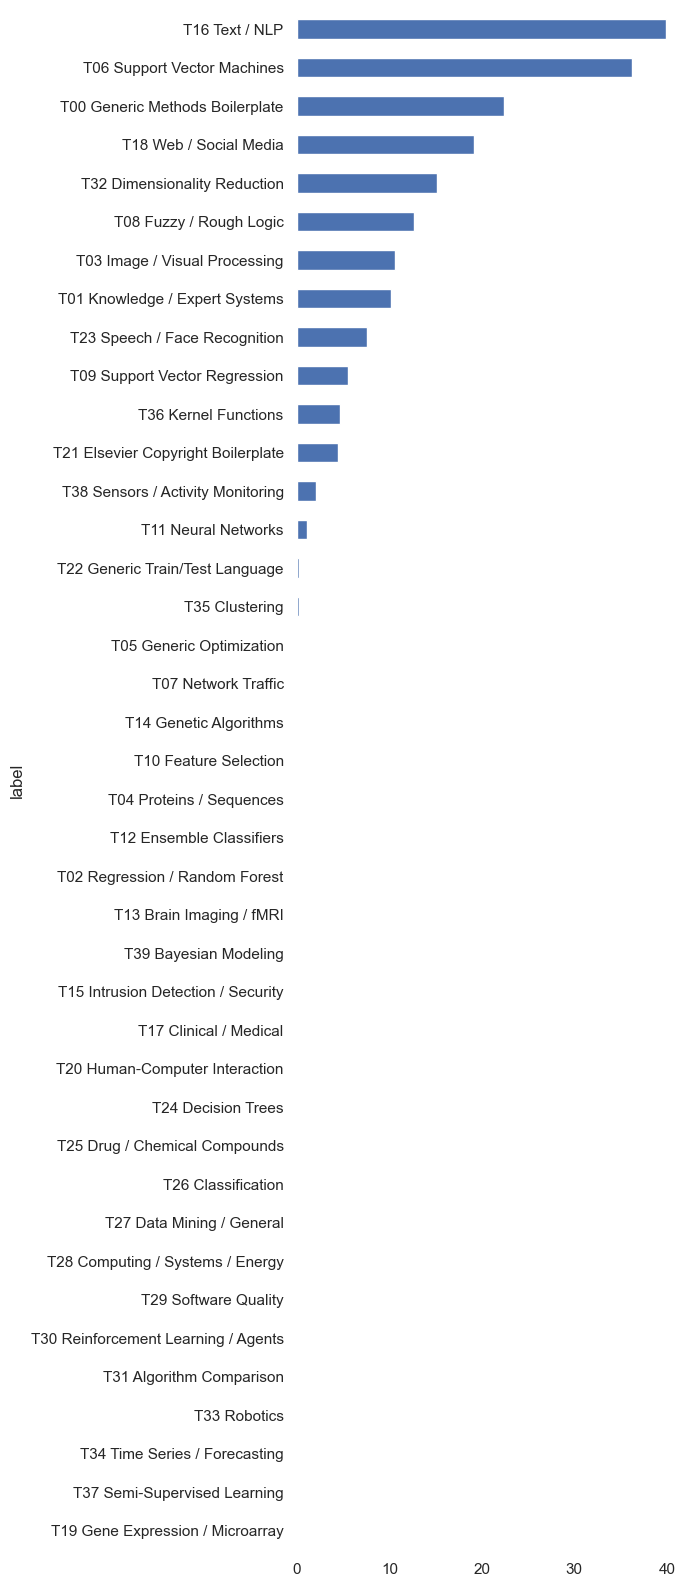

In [48]:
TOPICS.sort_values('doc_weight_sum', 
    ascending=True).plot.barh(y='doc_weight_sum', x='label', 
    figsize=(5, n_topics/2), legend=False)
sns.despine(left=True, bottom=True)
plt.show()

In [49]:
TOPICS.group.value_counts()

group
Methodology            18
Application Domains    16
Artifact                6
Name: count, dtype: int64

In [53]:
top5 = (
    THETA.mean()
    .sort_values(ascending=False)
    .head(5)
)

for topic_id in top5.index:
    top_words = (
        PHI.loc[topic_id]
        .sort_values(ascending=False)
        .head(5)
        .index
        .tolist()
    )
    
    print(f"{topic_id}:")
    print("Top 5 words:", ", ".join(top_words))
    print("Mean document weight:", round(top5[topic_id], 4))
    print()

T16:
Top 5 words: the, of, shall, and, be
Mean document weight: 0.2078

T06:
Top 5 words: the, of, and, to, article
Mean document weight: 0.1886

T00:
Top 5 words: the, of, and, to, share
Mean document weight: 0.1164

T18:
Top 5 words: the, of, or, to, in
Mean document weight: 0.0995

T32:
Top 5 words: the, of, and, to, shall
Mean document weight: 0.0789



In [50]:
G = TOPICS.groupby("group")
midx = G.get_group("Methodology").index
aidx = G.get_group("Application Domains").index

In [52]:
DOCS.to_csv(f"{output_dir}/{data_prefix}-DOCS.csv", index=True)
THETA.to_csv(f"{output_dir}/{data_prefix}-THETA.csv", index=True)
PHI.to_csv(f"{output_dir}/{data_prefix}-PHI.csv", index=True)
TOPICS.to_csv(f"{output_dir}/{data_prefix}-TOPICS.csv", index=True)